# Codenames 5x5 Board Demo

This notebook demonstrates a complete game on a 5x5 board with full visibility. You can see:
- **Hidden Board**: What players see (unrevealed words)
- **Spymaster View**: The role of each word (friendly, opponent, neutral, assassin)
- **Game Progression**: Step-by-step gameplay with guess outcomes

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

from src.env.board import BoardConfig, load_words
from src.env.game import CodenamesGame
from src.env.visualization import plot_board
import matplotlib.pyplot as plt

## Step 1: Create a 5x5 Board Configuration

For a 5x5 board (25 total cells):
- **9 Friendly** (Blue team)
- **8 Opponent** (Red team)
- **7 Neutral** 
- **1 Assassin** (Bomb)

In [ ]:
# Load available words
words_file = PROJECT_ROOT / "data" / "raw" / "codenames_words.txt"
all_words = load_words(words_file)
print(f"Loaded {len(all_words)} words from {words_file}")

# Create 5x5 board configuration
config = BoardConfig(
    rows=5,
    cols=5,
    num_friendly=9,  # Blue team words
    num_opponent=8,  # Red team words
    num_neutral=7,   # Neutral words
    num_assassin=1,  # Bomb word
    seed=42           # For reproducibility
)
config.validate()
print(f"\n5x5 Board Configuration:")
print(f"  Total cells: {config.board_size}")
print(f"  Friendly (Blue): {config.num_friendly}")
print(f"  Opponent (Red): {config.num_opponent}")
print(f"  Neutral: {config.num_neutral}")
print(f"  Assassin (Bomb): {config.num_assassin}")

Loaded 400 words from /Users/aeshagandhi/Downloads/MIDS-Sp26/RL/Codenames-Spymaster-RL/data/raw/codenames_words.txt

5x5 Board Configuration:
  Total cells: 25
  Friendly (Blue): 9
  Opponent (Red): 8
  Neutral: 7
  Assassin (Bomb): 1


## Step 2: Generate the Board

In [ ]:
# Create and reset the game
game = CodenamesGame(words=all_words, config=config)
board = game.reset()

# Extract board words for reference
board_words = [[cell.word for cell in row] for row in board]
print("Board words:")
for i, row in enumerate(board_words):
    print(f"  Row {i}: {row}")

Board words:
  Row 0: ['SOLDIER', 'CARROT', 'ATLANTIS', 'UNDERTAKER', 'FRANCE']
  Row 1: ['FAN', 'DWARF', 'CHOCOLATE', 'TUBE', 'CANADA']
  Row 2: ['STREAM', 'POST', 'BRIDGE', 'SATELLITE', 'MEXICO']
  Row 3: ['BALL', 'BACK', 'BUFFALO', 'DRILL', 'ENGLAND']
  Row 4: ['PIANO', 'SCREEN', 'AUSTRALIA', 'RABBIT', 'DEGREE']


## Step 3: View the Board - Player Perspective

**Player View** - All words are hidden (tan/beige color). Players can see word locations but not roles.

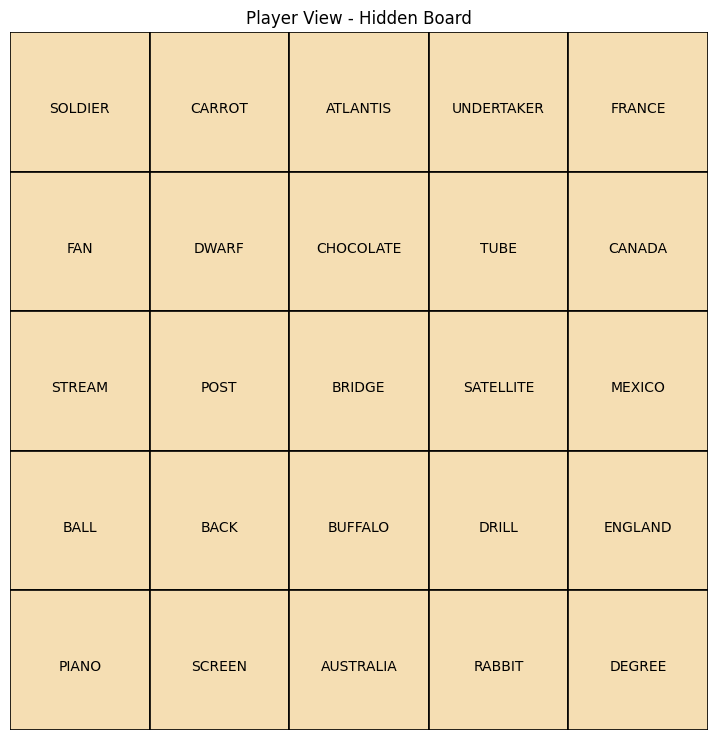

In [ ]:
# Show board as players see it (hidden)
plot_board(
    board,
    reveal_roles=False,
    reveal_revealed_only=False,
    title="Player View - Hidden Board",
    figsize_scale=1.5,
    font_size=10
)

## Step 4: View the Board - Spymaster Perspective

**Spymaster View** - The true roles are revealed:
- 🟩 **Green**: Friendly (Blue team) - 9 words
- 🟥 **Red**: Opponent (Red team) - 8 words
- ⬜ **Gray**: Neutral - 7 words
- ⬛ **Black**: Assassin (Bomb) - 1 word

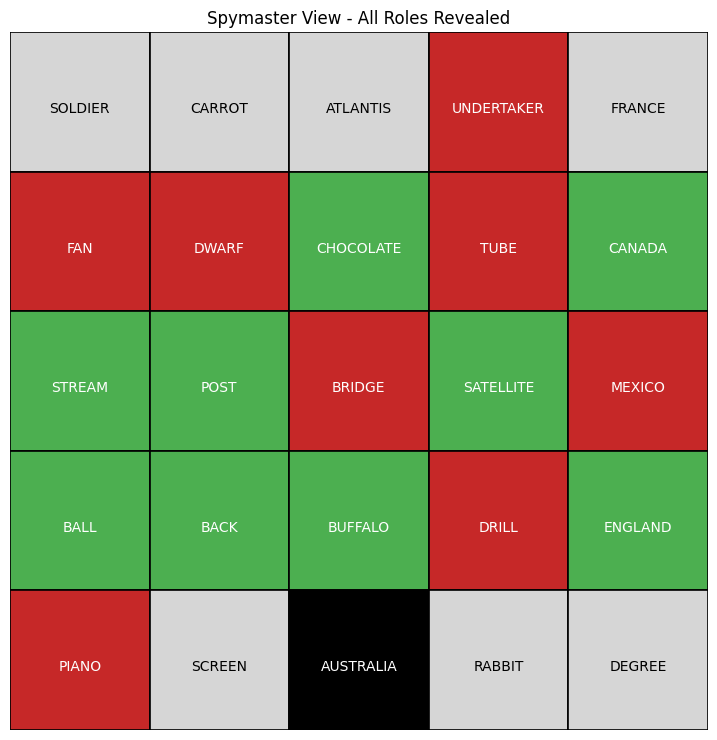

In [ ]:
# Show board as spymaster sees it (with roles revealed)
plot_board(
    board,
    reveal_roles=True,
    title="Spymaster View - All Roles Revealed",
    figsize_scale=1.5,
    font_size=10
)

## Step 5: Play Through the Game

Let's simulate some guesses and see how the board changes as words are revealed.

In [ ]:
# Get available actions (indices of unrevealed words)
available_actions = game.available_actions()
print(f"Available actions (word indices): {available_actions}")
print(f"Number of unrevealed words: {len(available_actions)}")

Available actions (word indices): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Number of unrevealed words: 25


In [ ]:
# Make some guesses
guesses = available_actions[:5]  # Guess first 5 unrevealed words
print(f"\nMaking {len(guesses)} guesses. Let's see what we hit!\n")

for i, guess_idx in enumerate(guesses):
    board, reward, done, info = game.step(guess_idx)
    word = info["word"]
    role = info["role"]
    
    reward_emoji = "✓" if role == "friendly" else "✗"
    print(f"Guess {i+1}: '{word}' -> {role.upper()} {reward_emoji} (Reward: {reward})")
    
    if done:
        print(f"Game Over! {info.get('reason', 'Game ended.')}")
        break


Making 5 guesses. Let's see what we hit!

Guess 1: 'SOLDIER' -> NEUTRAL ✗ (Reward: 0.0)
Guess 2: 'CARROT' -> NEUTRAL ✗ (Reward: 0.0)
Guess 3: 'ATLANTIS' -> NEUTRAL ✗ (Reward: 0.0)
Guess 4: 'UNDERTAKER' -> OPPONENT ✗ (Reward: 0.0)
Guess 5: 'FRANCE' -> NEUTRAL ✗ (Reward: 0.0)


## Step 6: View Board After Guesses

**Player View After Guesses** - Revealed words are now colored showing results.

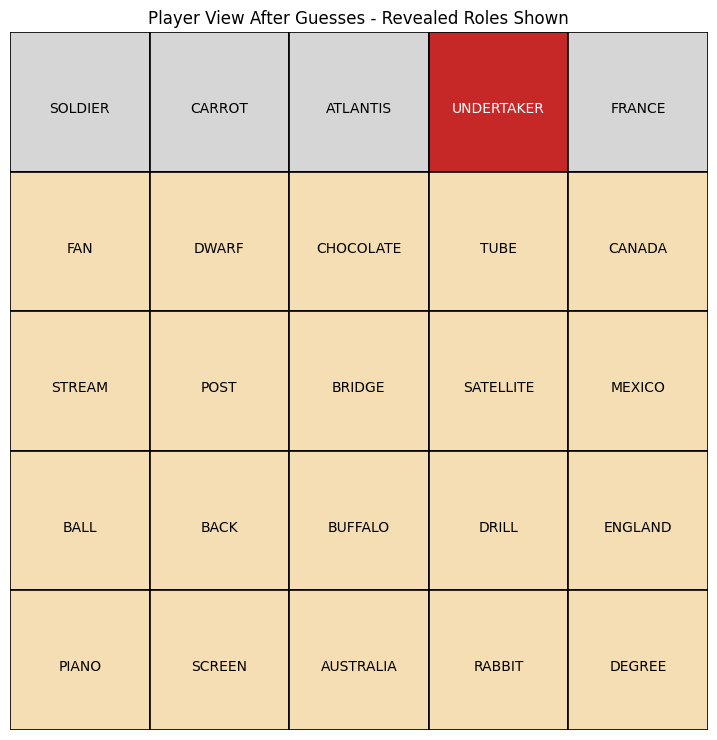

In [ ]:
# Show board after guesses (player view with revealed cells shown)
plot_board(
    board,
    reveal_roles=False,
    reveal_revealed_only=True,
    title="Player View After Guesses - Revealed Roles Shown",
    figsize_scale=1.5,
    font_size=10
)

## Step 7: Full Spymaster View with Guess Order

Shows the guess sequence with numbers in corners (Yellow = most recent).

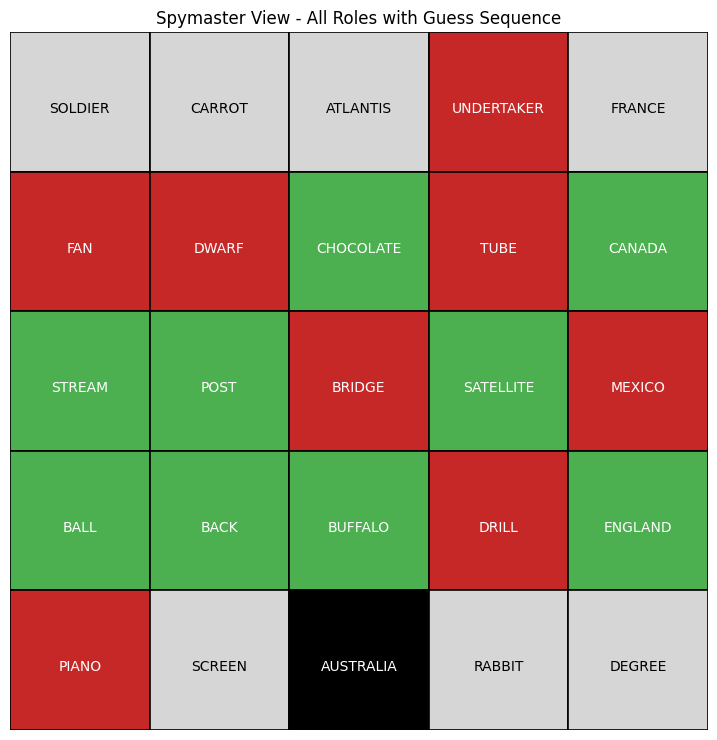

In [ ]:
# Show spymaster view with guess sequence
plot_board(
    board,
    reveal_roles=True,
    title="Spymaster View - All Roles with Guess Sequence",
    figsize_scale=1.5,
    font_size=10
)

## Summary Statistics

In [ ]:
from src.env.board import flatten_board

flat_board = flatten_board(board)
revealed_count = sum(1 for cell in flat_board if cell.revealed)
unrevealed_count = len(flat_board) - revealed_count

role_reveal_status = {}
for role in ["friendly", "opponent", "neutral", "assassin"]:
    total = sum(1 for cell in flat_board if cell.role == role)
    revealed = sum(1 for cell in flat_board if cell.role == role and cell.revealed)
    role_reveal_status[role] = {"total": total, "revealed": revealed}

print("Game Status:")
print(f"  Total revealed: {revealed_count}/25")
print(f"  Remaining unrevealed: {unrevealed_count}/25")
print(f"\nRole Status:")
print(f"  Friendly: {role_reveal_status['friendly']['revealed']}/{role_reveal_status['friendly']['total']} revealed")
print(f"  Opponent: {role_reveal_status['opponent']['revealed']}/{role_reveal_status['opponent']['total']} revealed")
print(f"  Neutral: {role_reveal_status['neutral']['revealed']}/{role_reveal_status['neutral']['total']} revealed")
print(f"  Assassin: {role_reveal_status['assassin']['revealed']}/{role_reveal_status['assassin']['total']} revealed")

Game Status:
  Total revealed: 5/25
  Remaining unrevealed: 20/25

Role Status:
  Friendly: 0/9 revealed
  Opponent: 1/8 revealed
  Neutral: 4/7 revealed
  Assassin: 0/1 revealed
